In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [37]:
iris = load_iris()

X = iris.data
y = iris.target

# Keep only two classes
mask = y < 2
X = X[mask]
y = y[mask]

# Convert labels to -1 and +1
y = np.where(y == 0, -1, 1)


In [38]:
X[:,2] = X[:,2] * 100


In [39]:
class Perceptron:
    
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.errors = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            error_count = 0
            for xi, target in zip(X, y):
                if target * (np.dot(xi, self.w) + self.b) <= 0:
                    self.w += self.lr * target * xi
                    self.b += self.lr * target
                    error_count += 1
            self.errors.append(error_count)


In [40]:
p1 = Perceptron(lr=0.0001, epochs=50)
p1.fit(X, y)


In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [42]:
p2 = Perceptron(lr=0.01, epochs=50)
p2.fit(X_scaled, y)


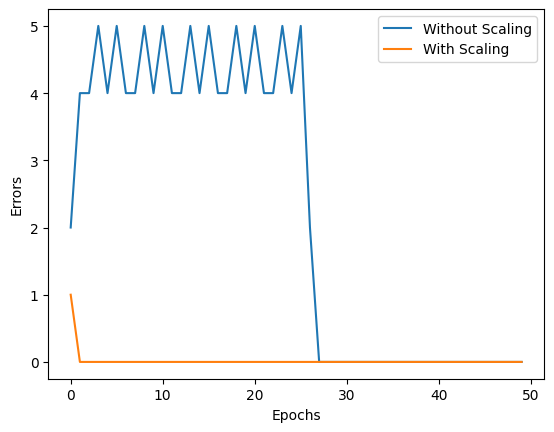

In [43]:
plt.plot(p1.errors, label="Without Scaling")
plt.plot(p2.errors, label="With Scaling")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Errors")
plt.show()
